In [1]:
from astropy import units as u
from astropy.coordinates import SkyCoord
from astropy.table import QTable
import astropy as a0
import numpy as np
import matplotlib.pyplot as plt
import math
import plotly
import plotly.graph_objs as go
import plotly.express as px
plotly.offline.init_notebook_mode()

In [2]:
c = {'Draco': {'ra': 15.*(17+20/60.+ 12.4/3600.)*u.deg, 'dec': (57+54/60.+55/3600.)*u.deg,\
                    'D':  75.8*u.kpc, 'v_r': -291.0*u.km/u.s,\
                    'mu_ra_cosd':   44.*10**(-3)*u.mas/u.yr, 'mu_dec': -188.*10**(-3)*u.mas/u.yr},\
       'Sculptor': {'ra': 15.*(1+  0/60.+  9.4/3600.)*u.deg, 'dec': (-33-42/60.-33/3600.)*u.deg,\
                    'D':  83.9*u.kpc, 'v_r':  111.4*u.km/u.s,\
                    'mu_ra_cosd':  100.*10**(-3)*u.mas/u.yr, 'mu_dec': -158.*10**(-3)*u.mas/u.yr},\
         'Fornax': {'ra': 15.*(2+ 39/60.+ 59.3/3600.)*u.deg, 'dec': (-34-26/60.-57/3600.)*u.deg, \
                    'D': 147.2*u.kpc, 'v_r':   55.3*u.km/u.s,\
                    'mu_ra_cosd':  381.*10**(-3)*u.mas/u.yr, 'mu_dec': -359.*10**(-3)*u.mas/u.yr},\
          'LeoII': {'ra': 15.*(11+13./60.+28.8/3600.)*u.deg, 'dec': (22+ 9/60.+ 6/3600.)*u.deg, \
                    'D': 233.0*u.kpc, 'v_r':   78.0*u.km/u.s,\
                    'mu_ra_cosd': -109.*10**(-3)*u.mas/u.yr, 'mu_dec': -150.*10**(-3)*u.mas/u.yr},\
           'LeoI': {'ra': 15.*(10+ 8./60.+28.1/3600.)*u.deg, 'dec': (12+18/60.+23/3600.)*u.deg,\
                    'D': 258.2*u.kpc, 'v_r':  282.5*u.km/u.s,\
                    'mu_ra_cosd':  -50.*10**(-3)*u.mas/u.yr, 'mu_dec': -120.*10**(-3)*u.mas/u.yr}}

set_of_icrs = {}

for dSph in c:
    set_of_icrs[dSph] = SkyCoord(ra=[c[dSph]['ra']], dec=[c[dSph]['dec']], distance=[c[dSph]['D']],\
                                 pm_ra_cosdec=[c[dSph]['mu_ra_cosd']], pm_dec = [c[dSph]['mu_dec']],\
                                 radial_velocity=[c[dSph]['v_r']], frame='icrs')
    
    sGC0 = set_of_icrs[dSph].transform_to(a0.coordinates.Galactocentric)

    if dSph=='Draco':
        sGC = sGC0.to_table()
        sGC = a0.table.hstack([sGC, QTable({'Name': [dSph]}, names=['Name'])])
    else:
        sGC = a0.table.vstack([sGC, a0.table.hstack([sGC0.to_table(), QTable({'Name': [dSph]}, names=['Name'])])], join_type='inner')

In [3]:
data = go.Scatter3d(x=sGC['x'], y=sGC['y'], z=sGC['z'], text = sGC['Name'], mode='markers', marker=dict(size=4), name='Dwarves')

fig = go.Figure(data)

for i, n in enumerate(sGC['Name']):
    fig.add_trace(
            go.Scatter3d(
                x=[sGC['x'][i].value, sGC['x'][i].value+sGC['v_x'][i].value],
                y=[sGC['y'][i].value, sGC['y'][i].value+sGC['v_y'][i].value],
                z=[sGC['z'][i].value, sGC['z'][i].value+sGC['v_z'][i].value],
                mode='lines', legendgroup=n,  hovertext=n,
                name="{}".format(n)  )  )

fig.update_layout(title='Figure 1.', 
                  autosize=True,
                  scene_camera_eye=dict(x=1.2, y=1.2, z=1.2),
                  scene = dict(
                    xaxis_title='X', yaxis_title='Y', zaxis_title='Z',
                    xaxis = dict(nticks=15,range=[-770,770],),
                    yaxis = dict(nticks=15,range=[-770,770],),
                    zaxis = dict(nticks=15,range=[-770,770],),),
                  width=550, height=550, template='none', scene_aspectmode='cube')
fig.show()

In [4]:
# P1: Orbit in its own plane
M = 1.5*10**12*u.kg*2*10**30 # MW halo
G = a0.constants.G

def ecc(r0, v0, vtau0):
    return np.sqrt(1.+4.*(vtau0.to(u.m/u.s))**2*r0.to(u.m)/2./G/M*((v0.to(u.m/u.s))**2*r0.to(u.m)/2./G/M-1)).value

def a_ax(r0, v0):
    return (r0.to(u.m)/(1-(v0.to(u.m/u.s))**2*r0.to(u.m)/2./G/M)/2.).to(u.kpc).value

def angl_ecc(rc, e0, a0):
    psihalf = np.arctan(np.sqrt(2/(1./e0*(1-rc/a0)+1)-1.))
    if rc>a0:
        psihalf += np.pi
    return (psihalf*2)

def angl_c(psic, e0):
    # prepare psic (current psi) 0, 2pi
    # so psic/2. 0, pi
    theta_signed = np.arctan(np.sqrt((1+e0)/(1-e0))*np.tan(psic/2))
    if psic-np.pi > np.pi/2.:
        theta_signed +=np.pi
    theta = 2.*theta_signed
    return theta

def rc(psic, e0, a0):
    return a0*(1-e0*np.cos(psic))

In [5]:
# P2: Angles and rotational (final) matrix:
def rot_matrix(phi, ax=0, dim=3):
    # Counterclockwise rot per pi of coord.sys.
    init = np.zeros((dim,dim))
    for i in np.asarray(range(dim)):
        for j in np.asarray(range(dim)):
            if i!= j:
                init[i][j] = np.sin(phi)* ((j-i)/abs(i-j))*(-1)**(i+j)
            else: init[i][j] = np.cos(phi)

    for i in np.asarray(range(dim)):
        for j in np.asarray(range(dim)):
            if i==ax or j==ax:
                init[i][j] = 0.
            if i==j==ax:
                init[i][j] = 1

    return init

def vect_m(a, b):
    return np.array([a[1]*b[2]-a[2]*b[1],\
                  -1*a[0]*b[2]+a[2]*b[0],\
                     a[0]*b[1]-a[1]*b[0]])

In [6]:
def reverse_tr(x, y, z, vtau, phi4):
    
    p0 = np.array([x,y,z])
    v0 = vtau    
    alpha = np.arctan(abs(p0[1]/p0[0]))
    if p0[0]<0:
        phi1 = np.pi+alpha   if p0[1]<0 else np.pi-alpha
    else:
        phi1 = 2*np.pi-alpha if p0[1]<0 else alpha
    r1 = rot_matrix(phi1, ax=2)

    p1 = np.dot(rot_matrix(-1*phi1, ax=2), p0)
    v1 = np.dot(rot_matrix(-1*phi1, ax=2), v0)
    
    #print('Updated_point: ', p1)
    beta  = np.arctan(abs(p1[2]/p1[0]))

    if p1[0]<0:
        phi2 = np.pi+beta    if p1[2]>0 else np.pi-beta
    else:
        phi2 = 2*np.pi-beta  if p1[2]>0 else beta
    r2 = rot_matrix(phi2, ax=1)

    p2 = np.dot(rot_matrix(-1*phi2, ax=1), p1)
    v2 = np.dot(rot_matrix(-1*phi2, ax=1), v1)    
    
    #print('Vtau_test: ', v2)
    gamma = np.arctan(abs(v2[2]/v2[1]))
    
    if v2[1]<0: # updated y
        phi3 = np.pi+gamma   if v2[2]<0 else np.pi-gamma
    else:
        phi3 = 2*np.pi-gamma if v2[2]<0 else gamma

    r3 = rot_matrix(phi3, ax=0)
    r4 = rot_matrix(phi4*(-1), ax=2) # <-> phase angle: place pericenter phi4 behind the ch. point with the phase angle phi4.
    
    #print(alpha*180/np.pi, beta*180/np.pi, gamma*180/np.pi, phi1*180/np.pi, phi2*180/np.pi,phi3*180/np.pi,phi4*180/np.pi)
    
    return r1, r2, r3, r4

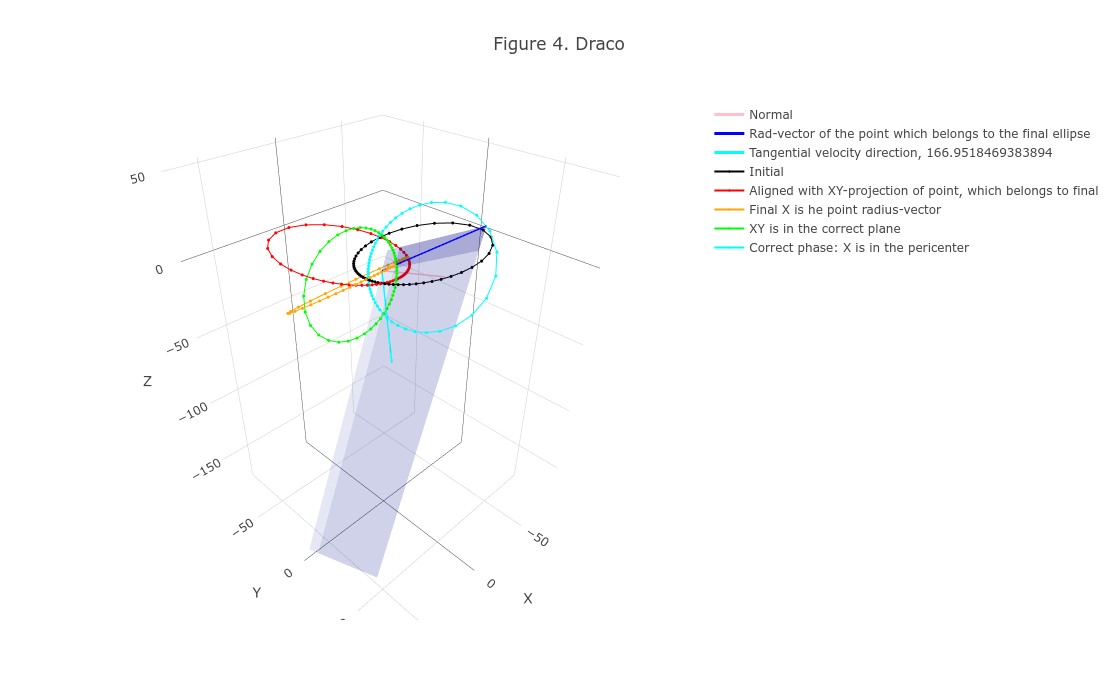

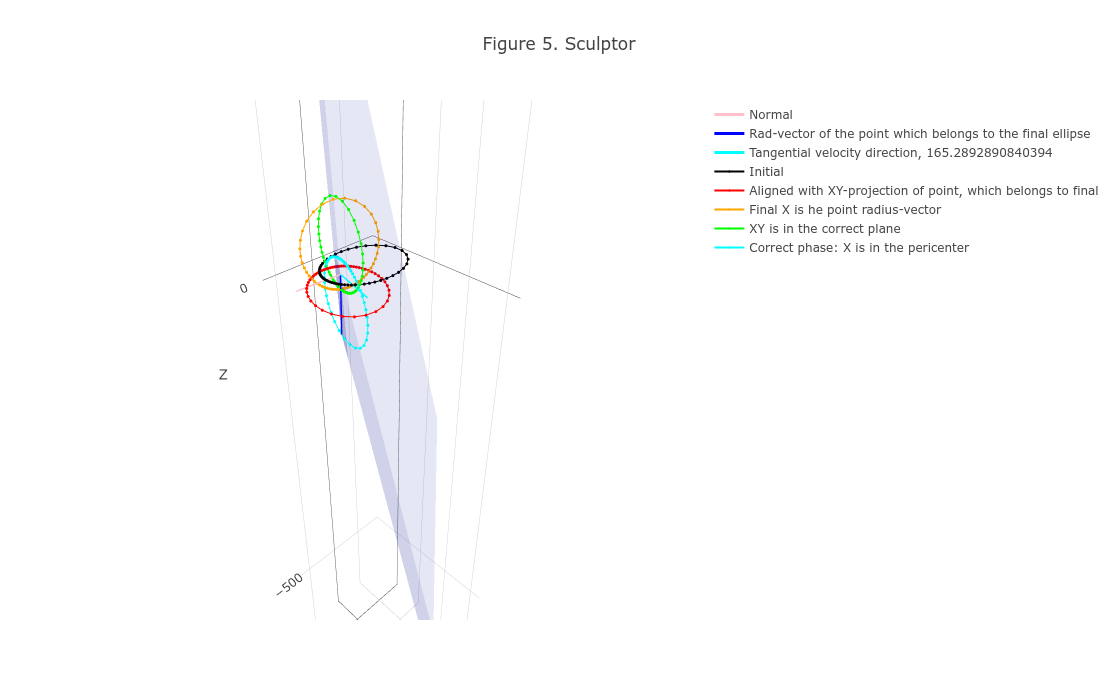

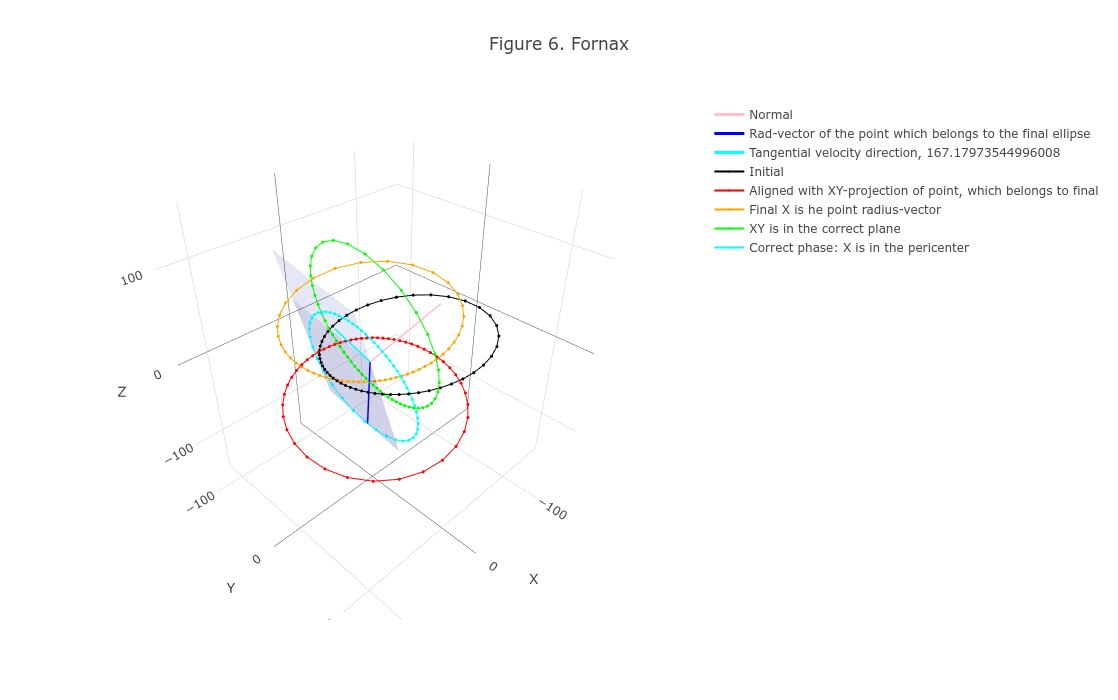

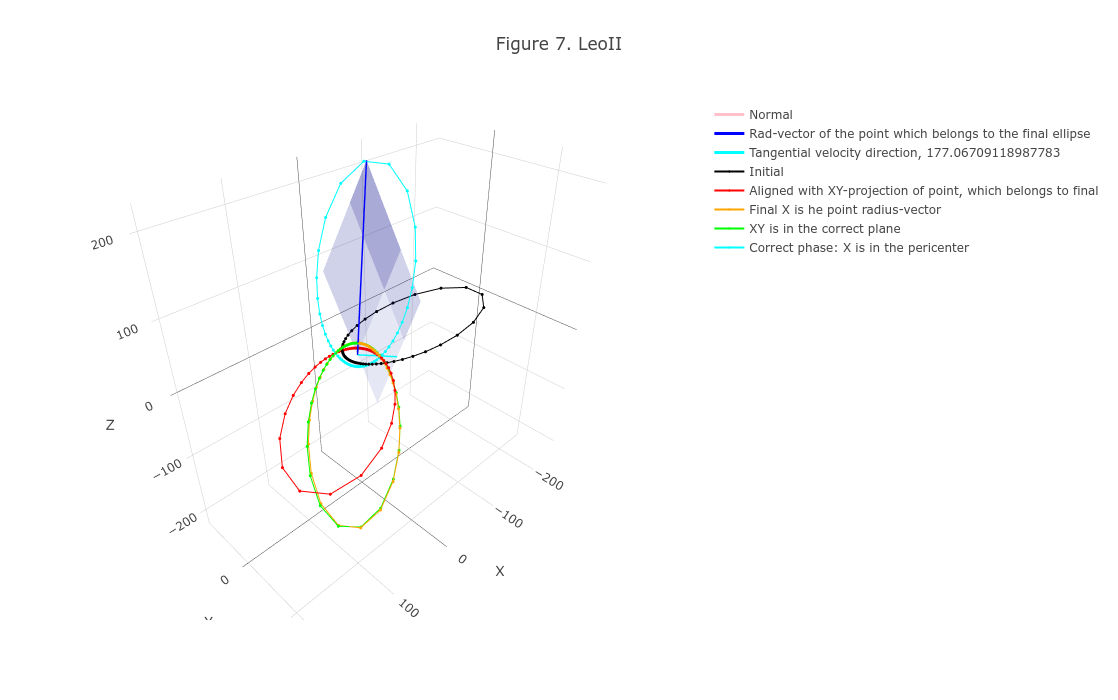

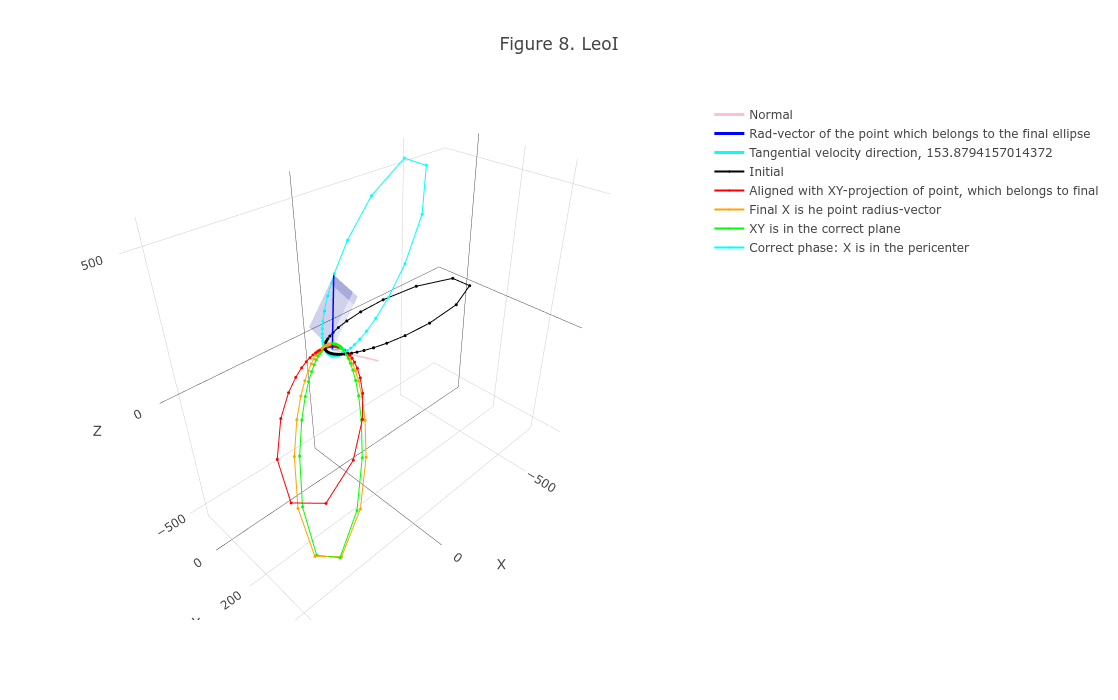

In [17]:
s = sGC

for i00, n in enumerate(s['Name']):
    
    #if i00!=0: break
    #if i00<2: continue
    r_dwarf = np.array([s['x'][i00].value, s['y'][i00].value, s['z'][i00].value])
    v_dwarf = np.array([s['v_x'][i00].value, s['v_y'][i00].value, s['v_z'][i00].value])
    
    r0 = np.sum(r_dwarf**2)**0.5; v0 = np.sum(v_dwarf**2)**0.5
    
    r_ort    = r_dwarf/r0
    norm_ort = vect_m(r_ort, v_dwarf)/np.sum(vect_m(r_ort, v_dwarf)**2)**0.5

    tau_ort  = vect_m(norm_ort, r_ort)  # vtau_test
    
    vr = v0*np.sum(r_ort*v_dwarf)/(np.sum(r_ort**2)**0.5*np.sum(v_dwarf**2)**0.5) * r_ort
    vt = tau_ort * np.sqrt(v0**2 - np.sum(vr**2))
    
    vt0 = np.sqrt(np.sum(vt**2))
    
    e = ecc(r0*u.kpc, v0*u.km/u.s, vt0*u.km/u.s)
    a = a_ax(r0*u.kpc, v0*u.km/u.s)
    
    psi_current = angl_ecc(r0, e, a)
    while abs(psi_current)>2*np.pi:
        psi_current +=2*np.pi*(-1*psi_current)/(abs(psi_current))
    
    phi4 = angl_c(psi_current, e)
    while abs(phi4)>2*np.pi:
        phi4 +=2*np.pi*(-1*phi4)/(abs(phi4))

    #Initialize orbit in its plane    
    x = np.array([0, r_dwarf[0], v_dwarf[0]])
    y = np.array([0, r_dwarf[1], v_dwarf[1]])
    
    z0      = lambda xl, yl: (xl*norm_ort[0] +yl*norm_ort[1])*(-1)/norm_ort[2]
    xv, yv  = np.meshgrid(x,y)
    zv      = z0(xv, yv)
    
    # Definition of the orbit in its own space:
    # r_dwarf - is our curent point with phi4 phase angle from pericenter
    ang = np.linspace(0, 2*np.pi, 50);
    
    xcircle = a*(1-e**2)/(1+e*np.cos(ang))*np.cos(ang)
    ycircle = a*(1-e**2)/(1+e*np.cos(ang))*np.sin(ang)
    zcircle = np.zeros(len(ang))

    # Create roational matrices 
    r1, r2, r3, r4 = reverse_tr(r_dwarf[0], r_dwarf[1], r_dwarf[2], vt, phi4)
    points1 = np.hstack([np.reshape(xcircle, (len(xcircle), 1)), np.reshape(ycircle, (len(xcircle), 1))])
    initial = np.hstack([points1, np.reshape(zcircle, (len(xcircle), 1))])
    
    # Application of rotational matrices step-by-step:
    ell1 = np.dot(r1, initial.T).T
    ell2 = np.dot(r1, np.dot(r2, initial.T)).T
    ell3 = np.dot(r1, np.dot(r2, np.dot(r3, initial.T))).T
    ell4 = np.dot(r1, np.dot(r2, np.dot(r3,np.dot(r4, initial.T)))).T
    
    # Figure: vectors and 3-axes of coordinates.
    
    fig = go.Figure(data=[go.Surface(x=x, y=y, z=zv, surfacecolor=np.full(zv.shape,'cyan'), opacity=0.1, showscale = False, name='Destination')])
    
    vectors    = np.array([[np.zeros(3,), norm_ort*a], [np.zeros(3,), r_dwarf], [np.zeros(3,), tau_ort*50]])
    vc_legends = ['Normal', 'Rad-vector of the point which belongs to the final ellipse',\
                  f'Tangential velocity direction, {phi4*180./np.pi}']
    vc_colors  = ['pink', 'blue', 'cyan']
    
    for i, v in enumerate(vectors):
        fig.add_trace(go.Scatter3d(x=[v[0][0], (v[1][0]-v[0][0])],\
                                   y=[v[0][1], (v[1][1]-v[0][1])],\
                                   z=[v[0][2], (v[1][2]-v[0][2])], mode='lines',\
                                   line = dict(color=vc_colors[i]) ,line_width=3,showlegend=True,name=vc_legends[i],))
    
    
    ell_legends = ['Initial', 'Aligned with XY-projection of point, which belongs to final',\
                   'Final X is he point radius-vector', 'XY is in the correct plane', 'Correct phase: X is in the pericenter']
    colors      = ['black', 'red', 'orange', 'lime', 'cyan']
    
    for i, d in enumerate([initial, ell1, ell2, ell3, ell4]):
        fig.add_trace(go.Scatter3d(x=d[:,0], y=d[:,1], z=d[:,2], line = dict(color=colors[i]),marker_size=1,showlegend=True,name=ell_legends[i],))
    
    
    fig.update_layout(title=f'Figure {4+i00}. {n}', autosize=True,
                      scene_camera_eye=dict(x=1.2, y=1.2, z=1.2),
                      scene = dict(xaxis_title='X', yaxis_title='Y', zaxis_title='Z',\
                                   xaxis = dict(nticks=5), yaxis = dict(nticks=5), zaxis = dict(nticks=5),),\
                      width=1000, height=700, template='none', scene_aspectmode='data')
    
    fig.show()

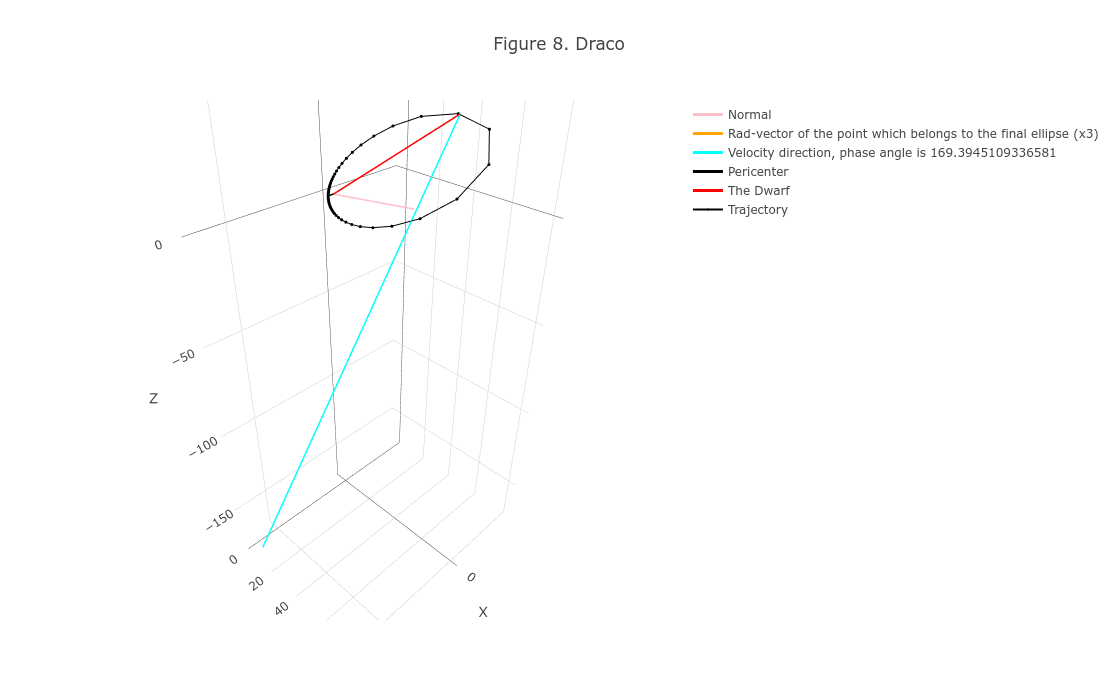

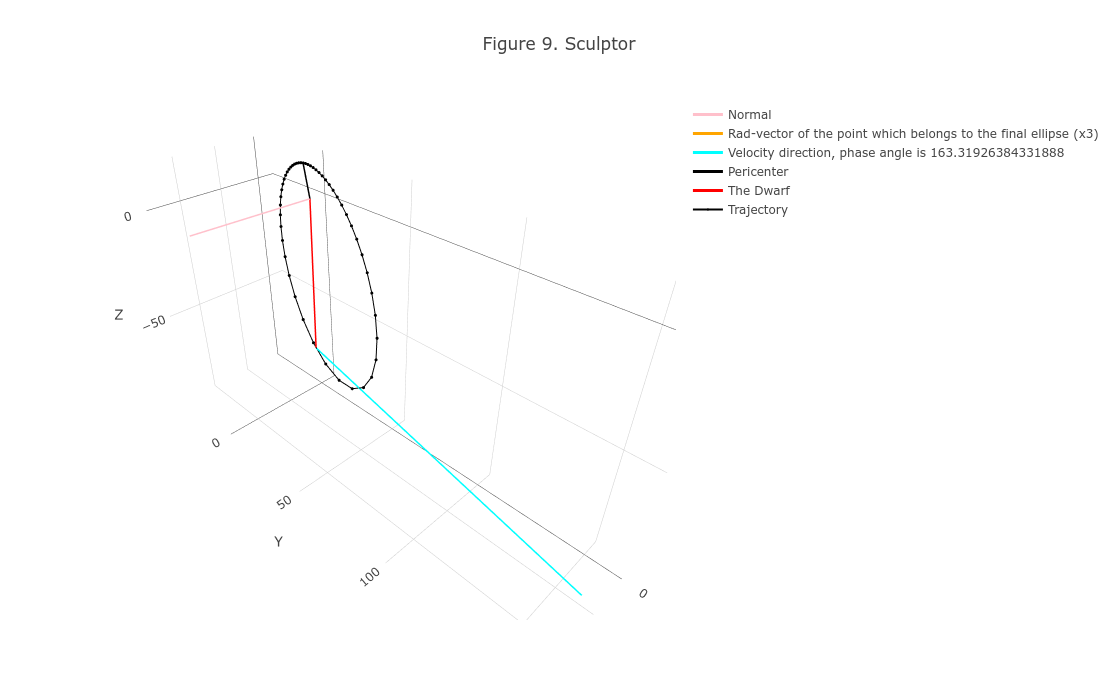

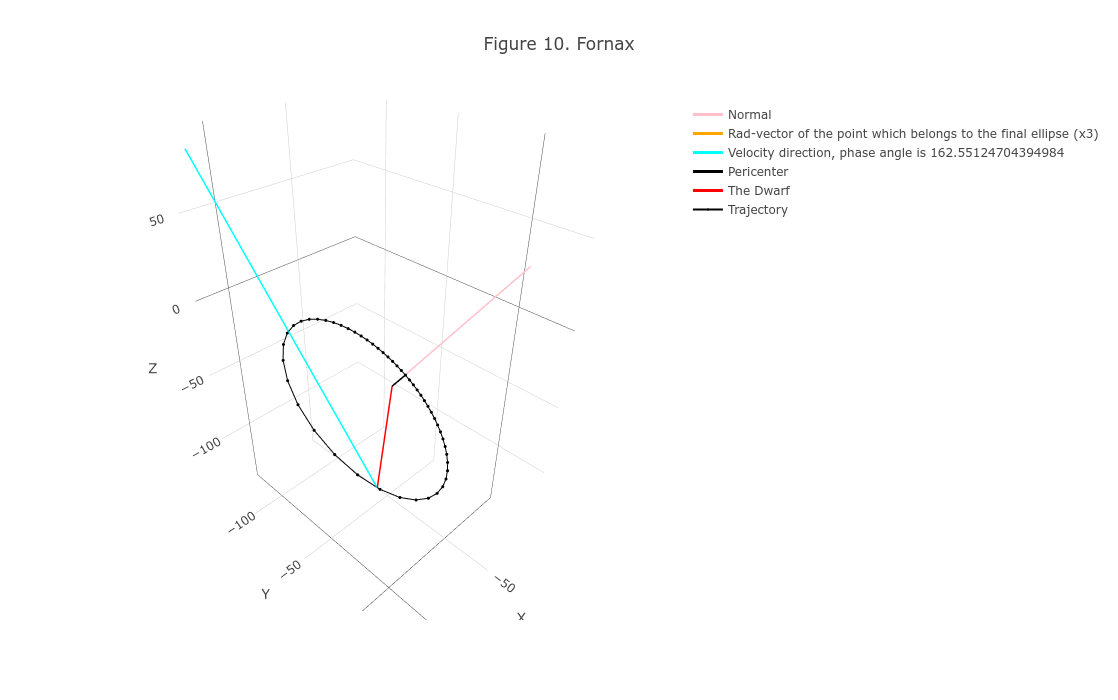

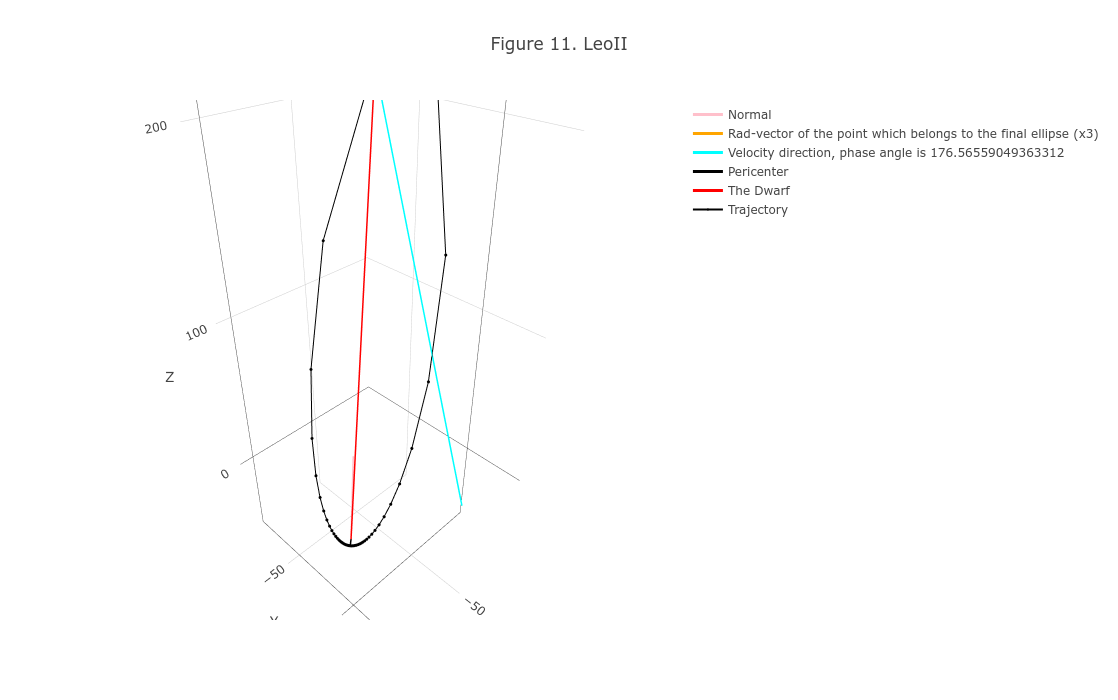

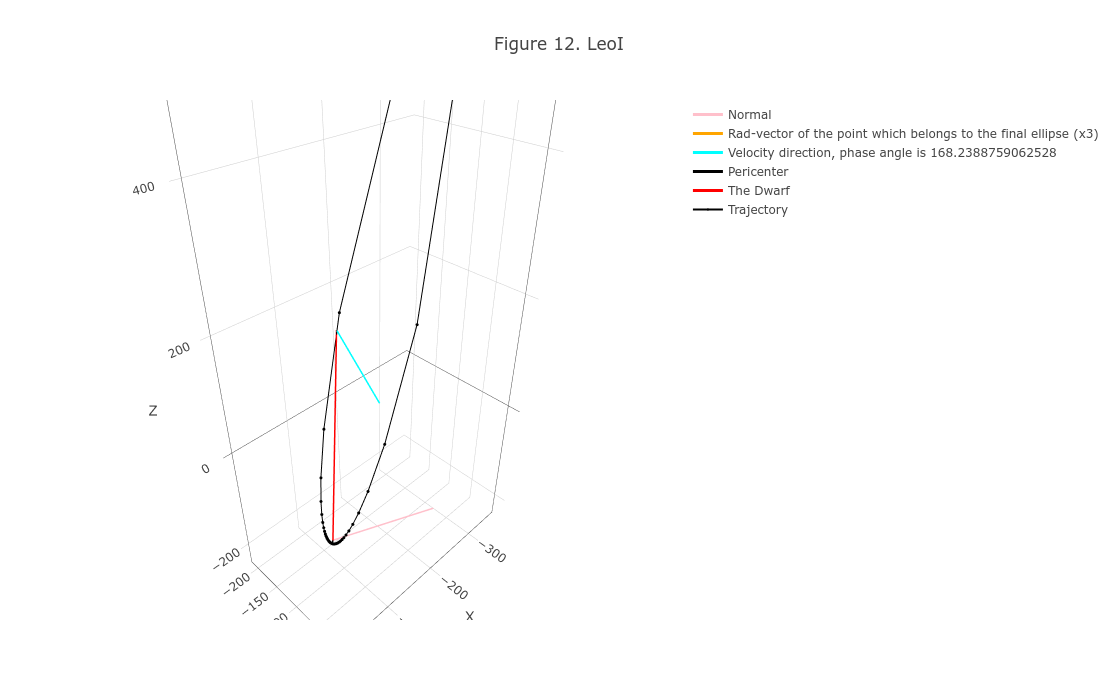

In [16]:
s = sGC

for i00, n in enumerate(s['Name']):
    
    r_dwarf = np.array([s['x'][i00].value, s['y'][i00].value, s['z'][i00].value])
    v_dwarf = np.array([s['v_x'][i00].value, s['v_y'][i00].value, s['v_z'][i00].value])
    
    r0 = np.sum(r_dwarf**2)**0.5; v0 = np.sum(v_dwarf**2)**0.5
    
    r_ort    = r_dwarf/r0
    norm_ort = vect_m(r_ort, v_dwarf)/np.sum(vect_m(r_ort, v_dwarf)**2)**0.5
    
    tau_ort  = vect_m(norm_ort, r_ort)  # vtau_test

    vt = (tau_ort*v_dwarf)*tau_ort

    vt0 = np.sqrt(np.sum(vt**2))
    
    e = ecc(r0*u.kpc, v0*u.km/u.s, vt0*u.km/u.s)
    a = a_ax(r0*u.kpc, v0*u.km/u.s)
    
    psi_current = angl_ecc(r0, e, a)
    while abs(psi_current)>2*np.pi:
        psi_current +=2*np.pi*(-1*psi_current)/(abs(psi_current))
    phi4 = angl_c(psi_current, e)
    
    while abs(phi4)>2*np.pi or phi4<0.:
        phi4 +=2*np.pi*(-1*phi4)/(abs(phi4))
    
    # Definition of the orbit in its own space:
    # r_dwarf - is our curent point with phi4 phase angle from pericenter
    ang = np.linspace(0, np.pi*2, 50);
    
    xcircle = a*(1-e**2)/(1+e*np.cos(ang))*np.cos(ang)
    ycircle = a*(1-e**2)/(1+e*np.cos(ang))*np.sin(ang)
    zcircle = np.zeros(len(ang))

    p1 = np.array([xcircle[0], ycircle[0], zcircle[0]])
    p2 = np.array([a*(1-e**2)/(1+e*np.cos(phi4))*np.cos(phi4),\
                  a*(1-e**2)/(1+e*np.cos(phi4))*np.sin(phi4), 0.])
    
    # Create roational matrices 
    r1, r2, r3, r4 = reverse_tr(r_dwarf[0], r_dwarf[1], r_dwarf[2], tau_ort, phi4)
    points1 = np.hstack([np.reshape(xcircle, (len(xcircle), 1)), np.reshape(ycircle, (len(xcircle), 1))])
    initial = np.hstack([points1, np.reshape(zcircle, (len(xcircle), 1))])
    
    # Application of rotational matrices step-by-step:
    ell1 = np.dot(r1, initial.T).T
    ell2 = np.dot(r1, np.dot(r2, initial.T)).T
    ell3 = np.dot(r1, np.dot(r2, np.dot(r3, initial.T))).T
    ell4 = np.dot(np.dot(r1, np.dot(r2, np.dot(r3,r4))), initial.T).T

    p1 = np.dot(np.dot(r1, np.dot(r2, np.dot(r3,r4))), p1)
    p2 = np.dot(np.dot(r1, np.dot(r2, np.dot(r3,r4))), p2)

    # Figure: vectors and 3-axes of coordinates.
    fig = go.Figure()
    
    vectors    = np.array([[np.zeros(3,), norm_ort*a], [np.zeros(3,), r_dwarf], [r_dwarf, r_dwarf+v_dwarf],\
                           [np.zeros(3,), p1], [np.zeros(3,), p2]])
    vc_legends = ['Normal', 'Rad-vector of the point which belongs to the final ellipse (x3)',\
                  f'Velocity direction, phase angle is {phi4*180./np.pi}', 'Pericenter', 'The Dwarf']
    vc_colors  = ['pink', 'orange', 'cyan', 'black', 'red']
    
    for i, v in enumerate(vectors):
        fig.add_trace(go.Scatter3d(x=[v[0][0], (v[1][0]-v[0][0])],\
                                   y=[v[0][1], (v[1][1]-v[0][1])],\
                                   z=[v[0][2], (v[1][2]-v[0][2])], mode='lines',\
                                   line = dict(color=vc_colors[i]) ,line_width=3,showlegend=True,name=vc_legends[i],))
    
    d = ell4
    fig.add_trace(go.Scatter3d(x=d[:,0], y=d[:,1], z=d[:,2], line = dict(color='black'),marker_size=1,showlegend=True,name='Trajectory'))
    
    fig.update_layout(title=f'Figure {8+i00}. {n}', autosize=True,
                      scene_camera_eye=dict(x=1.2, y=1.2, z=1.2),
                      scene = dict(xaxis_title='X', yaxis_title='Y', zaxis_title='Z',\
                                   xaxis = dict(nticks=5), yaxis = dict(nticks=5), zaxis = dict(nticks=5),),\
                      width=1000, height=700, template='none', scene_aspectmode='data')
    
    fig.show()